In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_t= pd.read_excel("../data/raw/RDSon_vs_Tj.xlsx")
df_r = pd.read_excel("../data/raw/mosfet_parameters.xlsx")

In [2]:
df_r.head()

,Parameter,Symbol,Min,Typ,Max,Unit,Condition
0,Drain-Source Voltage,VDS,NaN,NaN,120.0,V,Maximum rating
1,Drain Current,ID,NaN,NaN,300.0,A,"VGS=10V, DC current, Tj=25°C"
2,Threshold Voltage,VGS(th),2.6,3.1,3.6,V,"VDS=VGS, ID=270µA, Tj=25°C"
3,On-State Resistance,RDS(on),NaN,1.5,1.8,mΩ,"VGS=10V, ID=100A, Tj=25°C"
4,Maximum Junction Temperature,"Tj,max",NaN,NaN,175.0,°C,Operating temperature


In [3]:
Rth_JC = df_r.loc[
    df_r["Symbol"] == "RθJC", "Max"
].iloc[0]

Rth_JC

0.42

In [4]:
Tj_max = df_r.loc[
    df_r["Symbol"] == "Tj,max", "Max"
].iloc[0]
Tj_max

175.0

In [5]:
I = 100       # Drain Current [A]
Tc = 25       # Case Temperature [°C]

In [6]:
Tj = Tc
Rds_mohm = np.interp(
    Tj,
    df_t["Tj (°C)"],
    df_t["RDS(on) (mΩ)"]
)

print(Rds_mohm)

1.49


In [7]:
Rds = Rds_mohm / 1000
P_loss = I**2 * Rds
delta_T = P_loss*Rth_JC
Tj_new = Tc + delta_T

In [8]:
print("Current Tj:", Tj, "°C")
print("RDS(on):", Rds_mohm, "mΩ")
print("Conduction Loss:", P_loss, "W")
print("New Tj:", Tj_new, "°C")

Current Tj: 25 °C
RDS(on): 1.49 mΩ
Conduction Loss: 14.9 W
New Tj: 31.258 °C


In [9]:
Tj = Tj_new

Rds_mohm = np.interp(
    Tj,
    df_t["Tj (°C)"],
    df_t["RDS(on) (mΩ)"]
)

Rds = Rds_mohm / 1000

P_loss = I**2 * Rds

delta_T = P_loss * Rth_JC

Tj_new = Tc + delta_T

In [10]:
print("Current Tj:", Tj, "°C")
print("RDS(on):", Rds_mohm, "mΩ")
print("Conduction Loss:", P_loss, "W")
print("New Tj:", Tj_new, "°C")

Current Tj: 31.258 °C
RDS(on): 1.5400639999999999 mΩ
Conduction Loss: 15.40064 W
New Tj: 31.4682688 °C


In [11]:
Tj = Tc
tolerance = 0.001
max = 100
for r in range(max):
    Rds_mohm = np.interp(
        Tj,
        df_t["Tj (°C)"],
        df_t["RDS(on) (mΩ)"]
    )

    Rds = Rds_mohm / 1000

    P_loss = I**2 * Rds

    delta_T = P_loss * Rth_JC

    Tj_new = Tc + delta_T

    print(r + 1, Tj, "→", Tj_new)
    
    if abs(Tj_new - Tj) < tolerance:
        break
    else:
        Tj = Tj_new

1 25 → 31.258
2 31.258 → 31.4682688
3 31.4682688 → 31.47533383168
4 31.47533383168 → 31.47557121674445


In [12]:
Tc = 50
Tj = Tc
tolerance = 0.001
max = 100
for r in range(max):
    Rds_mohm = np.interp(
        Tj,
        df_t["Tj (°C)"],
        df_t["RDS(on) (mΩ)"]
    )

    Rds = Rds_mohm / 1000

    P_loss = I**2 * Rds

    delta_T = P_loss * Rth_JC

    Tj_new = Tc + delta_T

    print(r + 1, Tj, "→", Tj_new)
    
    if abs(Tj_new - Tj) < tolerance:
        break
    else:
        Tj = Tj_new

1 50 → 57.098
2 57.098 → 57.36034208
3 57.36034208 → 57.3700382432768
4 57.3700382432768 → 57.37039661347151


In [13]:
Tc_l = [25,50,75,100,125,150]

result_Tj = []
result_Rds = []
result_Ploss = []
tolerance = 0.001
max_iter = 100

for Tc in Tc_l:
    Tj = Tc
    print(f"\n=== Tc = {Tc} °C ===")
    
    for r in range(max_iter):
        Rds_mohm = np.interp(
            Tj,
            df_t["Tj (°C)"],
            df_t["RDS(on) (mΩ)"]
        )

        Rds = Rds_mohm / 1000

        P_loss = I**2 * Rds

        delta_T = P_loss * Rth_JC

        Tj_new = Tc + delta_T

        
        print(f"{r+1}회: {Tj:.3f} °C → {Tj_new:.3f} °C")
        if abs(Tj_new - Tj) < tolerance:
            break
        else:
            Tj = Tj_new
    result_Tj.append(Tj_new)
    result_Rds.append(Rds_mohm)
    result_Ploss.append(P_loss)



=== Tc = 25 °C ===
1회: 25.000 °C → 31.258 °C
2회: 31.258 °C → 31.468 °C
3회: 31.468 °C → 31.475 °C
4회: 31.475 °C → 31.476 °C

=== Tc = 50 °C ===
1회: 50.000 °C → 57.098 °C
2회: 57.098 °C → 57.360 °C
3회: 57.360 °C → 57.370 °C
4회: 57.370 °C → 57.370 °C

=== Tc = 75 °C ===
1회: 75.000 °C → 83.022 °C
2회: 83.022 °C → 83.372 °C
3회: 83.372 °C → 83.388 °C
4회: 83.388 °C → 83.388 °C

=== Tc = 100 °C ===
1회: 100.000 °C → 109.114 °C
2회: 109.114 °C → 109.527 °C
3회: 109.527 °C → 109.546 °C
4회: 109.546 °C → 109.547 °C

=== Tc = 125 °C ===
1회: 125.000 °C → 135.248 °C
2회: 135.248 °C → 135.764 °C
3회: 135.764 °C → 135.791 °C
4회: 135.791 °C → 135.792 °C
5회: 135.792 °C → 135.792 °C

=== Tc = 150 °C ===
1회: 150.000 °C → 161.508 °C
2회: 161.508 °C → 162.165 °C
3회: 162.165 °C → 162.203 °C
4회: 162.203 °C → 162.205 °C
5회: 162.205 °C → 162.205 °C


In [14]:
df_result = pd.DataFrame({
    "Tc (°C)": Tc_l,
    "Tj (°C)": result_Tj,
    "Rds (mΩ)": result_Rds,
    "Ploss (W)": result_Ploss
})
df_result

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W)
0,25,31.475571,1.541803,15.418027
1,50,57.370397,1.754856,17.548563
2,75,83.388375,1.997232,19.972321
3,100,109.547014,2.273099,22.730986
4,125,135.791909,2.569502,25.695021
5,150,162.205151,2.905988,29.059884


In [15]:
Rds_fixed_mohm = np.interp(
    25,
    df_t["Tj (°C)"],
    df_t["RDS(on) (mΩ)"]
)

Rds_fixed = Rds_fixed_mohm / 1000

P_loss_fixed = I**2 * Rds_fixed
print("Fixed RDS(on):", Rds_fixed_mohm, "mΩ")
print("Fixed Conduction Loss:", P_loss_fixed, "W")

Fixed RDS(on): 1.49 mΩ
Fixed Conduction Loss: 14.9 W


In [16]:
fixed_Tj = []
fixed_Ploss = []

for Tc in Tc_l:
    Tj_fixed = Tc + P_loss_fixed * Rth_JC

    fixed_Tj.append(Tj_fixed)
    fixed_Ploss.append(P_loss_fixed)

In [17]:
df_result["Fixed RDS Tj (°C)"] = fixed_Tj
df_result["Fixed RDS Loss (W)"] = fixed_Ploss

df_result

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W)
0,25,31.475571,1.541803,15.418027,31.258,14.9
1,50,57.370397,1.754856,17.548563,56.258,14.9
2,75,83.388375,1.997232,19.972321,81.258,14.9
3,100,109.547014,2.273099,22.730986,106.258,14.9
4,125,135.791909,2.569502,25.695021,131.258,14.9
5,150,162.205151,2.905988,29.059884,156.258,14.9


In [18]:
df_result["Tj Difference (°C)"] = (
    df_result["Tj (°C)"] - df_result["Fixed RDS Tj (°C)"]
)

df_result["Loss Difference (W)"] = (
    df_result["Ploss (W)"] - df_result["Fixed RDS Loss (W)"]
)

df_result

,Tc (°C),Tj (°C),Rds (mΩ),Ploss (W),Fixed RDS Tj (°C),Fixed RDS Loss (W),Tj Difference (°C),Loss Difference (W)
0,25,31.475571,1.541803,15.418027,31.258,14.9,0.217571,0.518027
1,50,57.370397,1.754856,17.548563,56.258,14.9,1.112397,2.648563
2,75,83.388375,1.997232,19.972321,81.258,14.9,2.130375,5.072321
3,100,109.547014,2.273099,22.730986,106.258,14.9,3.289014,7.830986
4,125,135.791909,2.569502,25.695021,131.258,14.9,4.533909,10.795021
5,150,162.205151,2.905988,29.059884,156.258,14.9,5.947151,14.159884


FileNotFoundError: [Errno 2] No such file or directory: '../figures/final_junction_temperature_comparison.png'

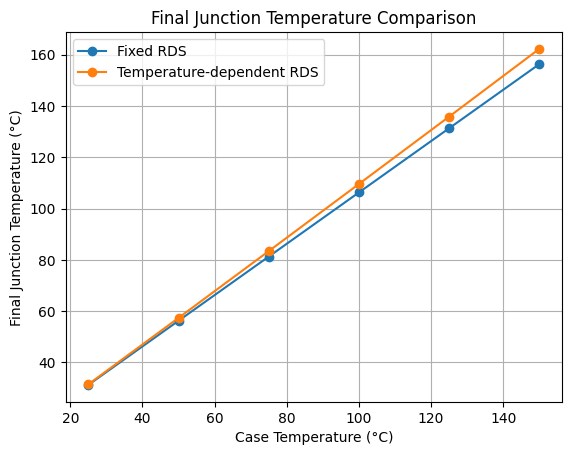

In [19]:
plt.plot(
    df_result["Tc (°C)"],
    df_result["Fixed RDS Tj (°C)"],
    marker="o",
    label="Fixed RDS"
)

plt.plot(
    df_result["Tc (°C)"],
    df_result["Tj (°C)"],
    marker="o",
    label="Temperature-dependent RDS"
)

plt.xlabel("Case Temperature (°C)")
plt.ylabel("Final Junction Temperature (°C)")
plt.title("Final Junction Temperature Comparison")
plt.grid()
plt.legend()
plt.savefig("../figures/final_junction_temperature_comparison.png", dpi=300)
plt.show()

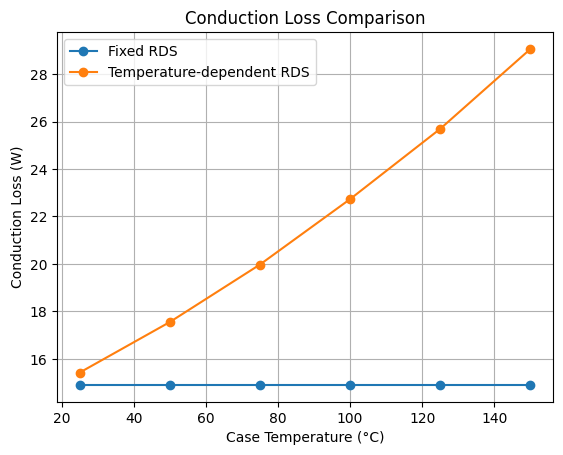

In [ ]:
plt.plot(
    df_result["Tc (°C)"],
    df_result["Fixed RDS Loss (W)"],
    marker="o",
    label="Fixed RDS"
)

plt.plot(
    df_result["Tc (°C)"],
    df_result["Ploss (W)"],
    marker="o",
    label="Temperature-dependent RDS"
)

plt.xlabel("Case Temperature (°C)")
plt.ylabel("Conduction Loss (W)")
plt.title("Conduction Loss Comparison")
plt.grid()
plt.legend()
plt.savefig("../figures/conduction_loss_comparison.png", dpi=300)
plt.show()

## Observation

- Case Temperature가 증가할수록 두 모델 모두 최종 Junction Temperature가 증가하였다.
- 25°C의 RDS(on)을 고정한 모델에서는 전도손실이 모든 Case Temperature 조건에서 14.9 W로 일정하였다.
- 반면 온도 의존 RDS(on)을 적용한 모델에서는 Junction Temperature가 상승함에 따라 RDS(on)이 증가하여 전도손실도 증가하였다.
- Tc = 25°C에서는 두 모델의 Junction Temperature 차이가 약 0.22°C로 작았으나, Tc = 150°C에서는 약 5.95°C까지 증가하였다.
- Tc = 150°C에서 온도 의존 모델의 전도손실은 약 29.06 W로, 고정 RDS 모델의 14.9 W보다 약 14.16 W 높게 나타났다.

## Interpretation

25°C에서의 RDS(on)을 모든 온도 조건에 동일하게 적용하면 고온에서 MOSFET의 전도손실을 과소평가할 수 있다.

실제 MOSFET에서는 Junction Temperature가 상승함에 따라 RDS(on)이 증가하고, 증가한 저항은 I²R 전도손실을 다시 증가시킨다. 따라서 전기적 손실과 열적 상태는 서로 독립적이지 않으며, 고온 조건의 Junction Temperature를 예측할 때는 온도 의존 RDS(on)을 고려할 필요가 있다.

본 분석에서는 Case Temperature를 각 조건에서 일정하게 유지하는 정상상태 모델을 사용하였으며, 시간에 따른 온도 변화는 포함하지 않았다.


## Next Step

본 분석은 정상상태 조건을 기반으로 하였으며,
이후 Transient Thermal Impedance를 이용하여
시간에 따른 Junction Temperature 변화를 분석할 예정이다.